# Clustering analysis

In [ ]:
from pathlib import Path
import pandas as pd
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1]  / "1" / "Features" 
PATIENT_PROFILES_NAME = "patient_profile_clustering.csv"

patients = pd.read_csv(FEATURE_PATH / PATIENT_PROFILES_NAME)

In [46]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4289 entries, 0 to 4288
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   subject_id               4289 non-null   int64  
 1   age                      4289 non-null   float64
 2   temp_max                 4289 non-null   float64
 3   sbp_max                  4289 non-null   float64
 4   hr_max                   4289 non-null   float64
 5   rr_max                   4289 non-null   float64
 6   spo2_min                 4289 non-null   float64
 7   lvef_min                 4289 non-null   float64
 8   hf_severity_max          4289 non-null   int64  
 9   lv_dilated               4289 non-null   float64
 10  mitral_regurgitation     4289 non-null   float64
 11  coronary_artery_disease  4289 non-null   float64
 12  atrial_fibrillation      4289 non-null   float64
 13  severe_stenosis          4289 non-null   float64
 14  pulmonary_hypertension  

In [47]:
missing_cols = patients.columns[patients.isna().sum() > 0]
print(missing_cols)


Index(['total_tests', 'perc_invalid', 'k_max', 'glu_max', 'creat_max',
       'k_abnormal_ratio', 'glu_abnormal_ratio', 'creat_abnormal_ratio',
       'total_procedures', 'n_days_span_y'],
      dtype='object')


In [48]:
patients_missing = patients[missing_cols]
patients_missing.head()

,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y
0,217.0,0.398,4.5,163.0,2.3,0.000,0.679,1.000,7.0,0.0
1,49.0,0.347,3.6,395.0,1.0,0.500,1.000,0.000,2.0,0.0
2,364.0,0.330,5.6,140.0,1.2,0.176,0.688,0.188,8.0,14.0
3,24.0,0.250,5.1,92.0,1.0,0.000,0.000,0.000,NaN,NaN
4,135.0,0.319,4.1,111.0,1.0,0.000,0.800,0.000,2.0,0.0


We can substitute the missing values on these columns with 0. 

In [49]:
patients = patients.fillna(0)
patients.isna().sum()

subject_id                 0
age                        0
temp_max                   0
sbp_max                    0
hr_max                     0
rr_max                     0
spo2_min                   0
lvef_min                   0
hf_severity_max            0
lv_dilated                 0
mitral_regurgitation       0
coronary_artery_disease    0
atrial_fibrillation        0
severe_stenosis            0
pulmonary_hypertension     0
wall_motion_abnormality    0
st_elevation               0
lbbb                       0
pleural_effusion           0
pulmonary_edema            0
pericardial_effusion       0
total_tests                0
perc_invalid               0
k_max                      0
glu_max                    0
creat_max                  0
k_abnormal_ratio           0
glu_abnormal_ratio         0
creat_abnormal_ratio       0
total_procedures           0
n_days_span_y              0
dtype: int64

## Normalization

Before digging into the clustering analysis, we have to normalize the data we've obtained in the previous task. 

We use `scikit-learn` tools to scale the features.

In [50]:
!pip install scikit-learn

In [51]:
patients.head()

,subject_id,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,mitral_regurgitation,coronary_artery_disease,atrial_fibrillation,severe_stenosis,pulmonary_hypertension,wall_motion_abnormality,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y
0,10000980,75.0,98.1,200.0,65.0,26.0,100.0,0.0,1,0.0,3.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,217.0,0.398,4.5,163.0,2.3,0.000,0.679,1.000,7.0,0.0
1,10002013,0.0,99.4,157.0,118.0,24.0,96.0,0.0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49.0,0.347,3.6,395.0,1.0,0.500,1.000,0.000,2.0,0.0
2,10002155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,364.0,0.330,5.6,140.0,1.2,0.176,0.688,0.188,8.0,14.0
3,10004457,66.0,0.0,0.0,0.0,0.0,98.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.250,5.1,92.0,1.0,0.000,0.000,0.000,0.0,0.0
4,10007058,48.0,98.2,123.0,63.0,21.0,99.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.319,4.1,111.0,1.0,0.000,0.800,0.000,2.0,0.0


We delete the `subject_id` column for the clustering part.

In [52]:
X = patients.drop(columns=['subject_id'])
X.head()

,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,mitral_regurgitation,coronary_artery_disease,atrial_fibrillation,severe_stenosis,pulmonary_hypertension,wall_motion_abnormality,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y
0,75.0,98.1,200.0,65.0,26.0,100.0,0.0,1,0.0,3.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,217.0,0.398,4.5,163.0,2.3,0.000,0.679,1.000,7.0,0.0
1,0.0,99.4,157.0,118.0,24.0,96.0,0.0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49.0,0.347,3.6,395.0,1.0,0.500,1.000,0.000,2.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,364.0,0.330,5.6,140.0,1.2,0.176,0.688,0.188,8.0,14.0
3,66.0,0.0,0.0,0.0,0.0,98.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.0,0.250,5.1,92.0,1.0,0.000,0.000,0.000,0.0,0.0
4,48.0,98.2,123.0,63.0,21.0,99.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.319,4.1,111.0,1.0,0.000,0.800,0.000,2.0,0.0


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    scaled_data, 
    columns=X.columns,
    index=X.index
)

X_scaled.head()

,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,mitral_regurgitation,coronary_artery_disease,atrial_fibrillation,severe_stenosis,pulmonary_hypertension,wall_motion_abnormality,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y
0,1.687920,0.365440,1.974078,0.598239,1.698573,0.481739,-0.618501,0.150391,-0.839055,1.399076,-0.165243,-0.400946,1.968213,1.183263,1.144395,-0.202533,-0.211715,-0.385930,4.452009,-0.571517,0.087504,0.567528,-0.230504,-0.098957,0.342957,-0.407187,0.084154,1.405160,1.045007,-0.147195
1,-0.625844,0.378518,1.335830,1.811946,1.498730,0.390081,-0.618501,0.150391,-0.839055,-0.953808,6.051678,-0.400946,1.968213,-0.845120,-0.873824,-0.202533,-0.211715,2.591144,-0.224618,-0.571517,-0.660881,0.161483,-1.482463,2.562230,-0.446338,3.802202,1.008391,-0.868168,-0.398389,-0.147195
2,-0.625844,-0.621451,-0.994518,-0.890270,-0.899387,-1.809713,-0.618501,-0.631460,-0.839055,-0.953808,-0.165243,-0.400946,-0.508075,-0.845120,-0.873824,-0.202533,4.723323,-0.385930,-0.224618,-0.571517,0.742341,0.026135,1.299668,-0.362781,-0.324908,1.074518,0.110067,-0.440782,1.333686,-0.085536
3,1.410269,-0.621451,-0.994518,-0.890270,-0.899387,0.435910,-0.618501,-0.631460,-0.839055,-0.953808,-0.165243,-0.400946,-0.508075,-0.845120,-0.873824,-0.202533,-0.211715,-0.385930,-0.224618,-0.571517,-0.772248,-0.610799,0.604136,-0.913371,-0.446338,-0.407187,-1.870852,-0.868168,-0.975748,-0.147195
4,0.854965,0.366446,0.831169,0.552438,1.198965,0.458825,-0.618501,-0.631460,-0.839055,-0.953808,-0.165243,-0.400946,-0.508075,-0.845120,-0.873824,-0.202533,-0.211715,-0.385930,-0.224618,-0.571517,-0.277779,-0.061444,-0.786930,-0.695429,-0.446338,-0.407187,0.432542,-0.868168,-0.398389,-0.147195


We can use **RobustScaler**: it is less sensible to outliers

In [54]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled_data = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    scaled_data, 
    columns=X.columns,
    index=X.index
)

## Clustering analysis: K-means

### Find the best K

#### Knee method

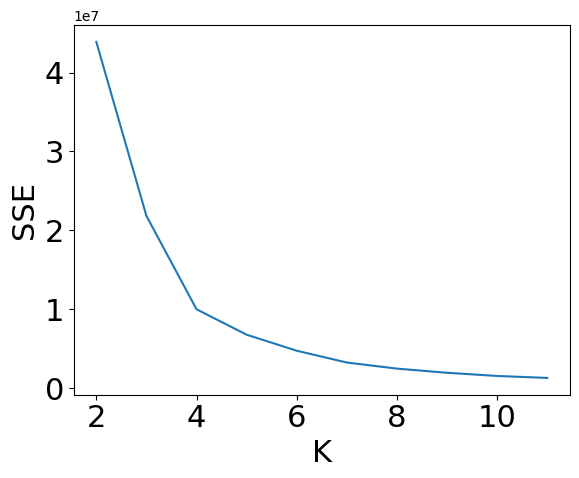

In [55]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse_list = list()
max_k = 11
for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100)
    kmeans.fit(X_scaled)
    
    sse = kmeans.inertia_
    sse_list.append(sse)

plt.plot(range(2, len(sse_list) + 2), sse_list)
plt.ylabel('SSE', fontsize=22)
plt.xlabel('K', fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.show()

#### Silhouette score

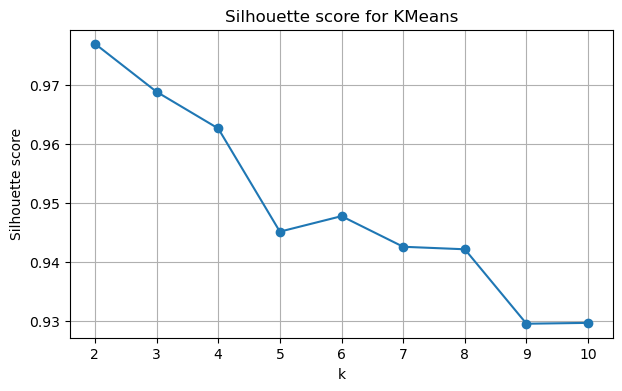

Best k by silhouette: 2


In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Range of k to try
K = range(2, 11)

sil_scores = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Silhouette plot
plt.figure(figsize=(7, 4))
plt.plot(K, sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette score for KMeans')
plt.xticks(list(K))
plt.grid(True)
plt.show()

best_k = K[sil_scores.index(max(sil_scores))]
print("Best k by silhouette:", best_k)


### Characterizations of the clusters 

In [57]:
k_opt = best_k  
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

# Attach cluster labels to the patient dataframe
patients['cluster_kmeans'] = cluster_labels
patients[['subject_id', 'cluster_kmeans']].head()


,subject_id,cluster_kmeans
0,10000980,0
1,10002013,0
2,10002155,0
3,10004457,0
4,10007058,0


In [58]:
cluster_profile = patients.groupby('cluster_kmeans').mean(numeric_only=True)
cluster_profile

,subject_id,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,mitral_regurgitation,coronary_artery_disease,atrial_fibrillation,severe_stenosis,pulmonary_hypertension,wall_motion_abnormality,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.501458e+07,20.441427,61.353803,66.510864,38.587388,8.921115,78.826878,13.395843,0.800425,0.411195,1.207605,0.025980,0.137459,0.201937,0.414974,0.430326,0.038498,0.042277,0.128956,0.047237,0.244450,194.179499,0.326312,4.660061,170.800425,1.718729,0.048151,0.648709,0.379677,3.309872,10.226264
1,1.463740e+07,8.363636,94.130909,104.854545,61.109091,15.145455,90.509091,16.763636,1.363636,0.563636,1.872727,0.072727,0.218182,0.454545,0.545455,0.636364,0.109091,0.090909,0.181818,0.109091,0.381818,441.945455,0.357927,5.100000,235.254545,2.998182,0.064982,0.731655,0.552491,8.781818,1819.018182


### Evaluation of clustering results

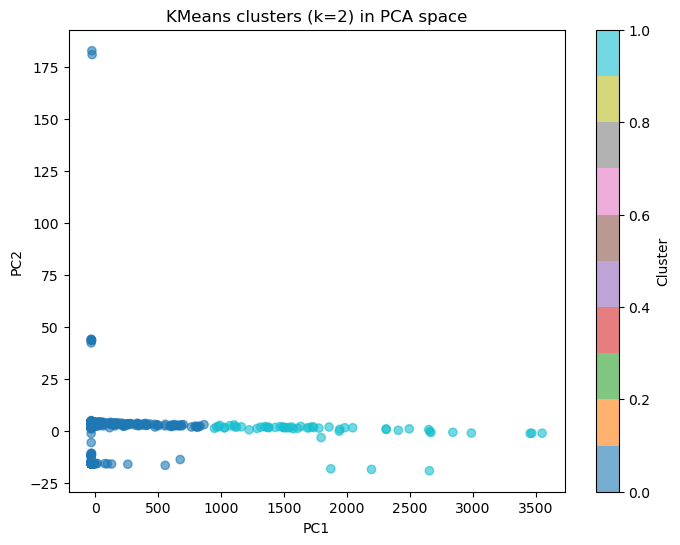

In [59]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap='tab10',
    alpha=0.6
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'KMeans clusters (k={k_opt}) in PCA space')
plt.colorbar(scatter, label='Cluster')
plt.show()


/home/gabriele/miniconda3/envs/DADH/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/tmp/ipykernel_26795/3633482065.py:21: UserWarning: Adding colorbar to a different Figure <Figure size 800x600 with 3 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cbar = plt.colorbar(scatter, label='Cluster', ticks=np.arange(k_opt))


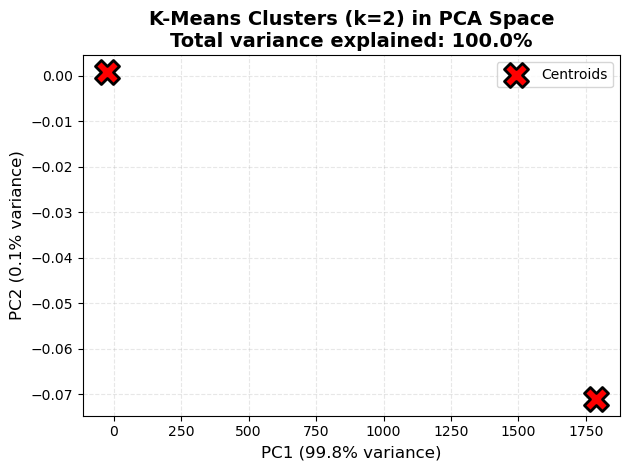

In [60]:
centroids_pca = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red',
    marker='X',
    s=300,
    edgecolors='black',
    linewidth=2,
    label='Centroids',
    zorder=10  # Porta i centroidi in primo piano
)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'K-Means Clusters (k={k_opt}) in PCA Space\nTotal variance explained: {pca.explained_variance_ratio_.sum():.1%}', 
          fontsize=14, fontweight='bold')

# CHIAVE: Colorbar DISCRETA invece di continua
cbar = plt.colorbar(scatter, label='Cluster', ticks=np.arange(k_opt))
cbar.set_label('Cluster', fontsize=12)
cbar.ax.set_yticklabels([f'Cluster {i}' for i in range(k_opt)])  # Etichette esplicite

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

**Possible interpretation**

With `k=2`, the clusters essentially represent two broad cardiometabolic risk profiles.

**Cluster 0 (healthier/lower risk)**
Younger patients, with lower hf_severity_max, fewer comorbidities (e.g., lv_dilated, atrial_fibrillation ≈ 0), and fewer total procedures/lab events.

**Cluster 1 (more complex/higher risk)**
Older patients, with higher blood pressure, heart rate, and hf_severity_max, a greater presence of structural comorbidities, and a higher number of tests/procedures; these are the "high-intensity care" patients.

## Clustering analysis: Density-based clustering (DBSCAN)

Before doing the analysis, we tune the hyperparameters (`eps`, `min_samples`) with a grid search. 

In [61]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

eps_values = [1.0, 5.0, 10.0, 15.0]
min_samples_values = [1,3,5]

best_eps = None
best_min_samples = None
best_sil = -1.0
best_labels = None

results = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        if n_clusters >= 2 and n_noise < len(labels):
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask])
        else:
            sil = np.nan

        results.append((eps, ms, n_clusters, n_noise, sil))

        # update best combination
        if not np.isnan(sil) and sil > best_sil:
            best_sil = sil
            best_eps = eps
            best_min_samples = ms
            best_labels = labels

# print all results
for r in results:
    print(f"eps={r[0]:.2f}, min_samples={r[1]:2d} -> "
          f"clusters={r[2]}, noise={r[3]}, silhouette={r[4]}")

print("\nBest combination:")
print(f"eps={best_eps}, min_samples={best_min_samples}, silhouette={best_sil}")

eps=1.00, min_samples= 1 -> clusters=4120, noise=0, silhouette=0.005128031907091128
eps=1.00, min_samples= 3 -> clusters=23, noise=4138, silhouette=0.1675430402347689
eps=1.00, min_samples= 5 -> clusters=7, noise=4211, silhouette=0.26920545175759475
eps=5.00, min_samples= 1 -> clusters=219, noise=0, silhouette=0.32748443889675816
eps=5.00, min_samples= 3 -> clusters=10, noise=220, silhouette=0.434605056641565
eps=5.00, min_samples= 5 -> clusters=5, noise=242, silhouette=0.44111009261512485
eps=10.00, min_samples= 1 -> clusters=108, noise=0, silhouette=0.5618237787616988
eps=10.00, min_samples= 3 -> clusters=13, noise=109, silhouette=0.7579271142139667
eps=10.00, min_samples= 5 -> clusters=8, noise=132, silhouette=0.759715129773241
eps=15.00, min_samples= 1 -> clusters=73, noise=0, silhouette=0.5731827598845897
eps=15.00, min_samples= 3 -> clusters=13, noise=72, silhouette=0.7520918551312438
eps=15.00, min_samples= 5 -> clusters=8, noise=99, silhouette=0.7546426799909464

Best combinati

In [62]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
db_labels = dbscan.fit_predict(X_scaled)

patients['cluster_dbscan'] = db_labels  # save labels (-1 = noise)

# --- basic stats ---
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = np.sum(db_labels == -1)

print(f"DBSCAN - number of clusters (excluding noise): {n_clusters_db}")
print(f"DBSCAN - number of noise points: {n_noise_db}")

# silhouette only if at least 2 clusters and not all noise
if n_clusters_db >= 2:
    mask_core = db_labels != -1
    sil_db = silhouette_score(X_scaled[mask_core], db_labels[mask_core])
    print(f"DBSCAN silhouette (without noise): {sil_db:.3f}")
else:
    print("Silhouette not meaningful (less than 2 clusters).")


DBSCAN - number of clusters (excluding noise): 8
DBSCAN - number of noise points: 132
DBSCAN silhouette (without noise): 0.760


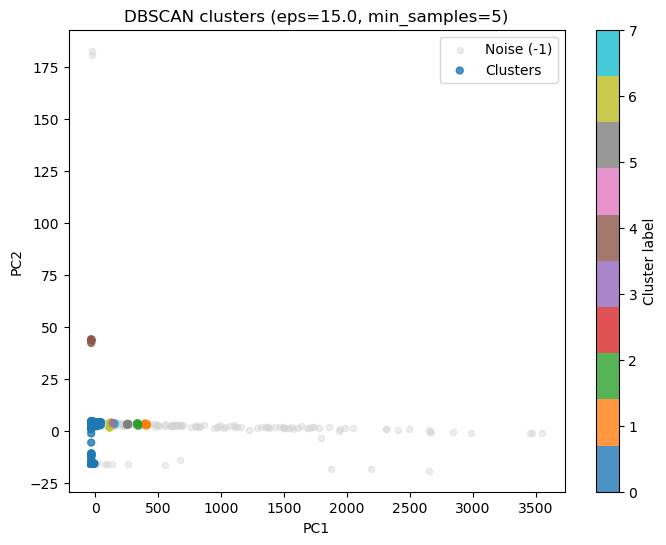

In [63]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

mask_noise = db_labels == -1
mask_cluster = ~mask_noise

# noise in grey
plt.scatter(
    X_pca[mask_noise, 0],
    X_pca[mask_noise, 1],
    c='lightgrey',
    s=20,
    alpha=0.4,
    label='Noise (-1)'
)

# clusters with colors
scatter = plt.scatter(
    X_pca[mask_cluster, 0],
    X_pca[mask_cluster, 1],
    c=db_labels[mask_cluster],
    cmap='tab10',
    s=25,
    alpha=0.8,
    label='Clusters'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN clusters (eps={eps}, min_samples={best_min_samples})')
plt.legend()
plt.colorbar(scatter, label='Cluster label')
plt.show()


In [64]:
dbscan_profile = (
    patients[patients['cluster_dbscan'] != -1]
    .groupby('cluster_dbscan')
    .mean(numeric_only=True)
    .round(2)
)

display(dbscan_profile)

# cluster sizes
patients['cluster_dbscan'].value_counts().sort_index()

,subject_id,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,mitral_regurgitation,coronary_artery_disease,atrial_fibrillation,severe_stenosis,pulmonary_hypertension,wall_motion_abnormality,st_elevation,lbbb,pleural_effusion,pulmonary_edema,pericardial_effusion,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y,cluster_kmeans
cluster_dbscan,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,15015770.99,20.56,58.90,65.66,37.81,8.79,77.83,13.33,0.78,0.41,1.19,0.03,0.14,0.20,0.41,0.42,0.04,0.04,0.12,0.05,0.24,183.88,0.33,4.65,169.25,1.68,0.05,0.65,0.38,3.15,1.37,0.0
1,14326512.50,36.00,100.30,137.33,79.17,21.33,96.17,22.50,1.33,0.67,1.67,0.00,0.00,0.33,0.67,0.67,0.00,0.17,0.17,0.17,0.17,306.33,0.32,4.65,157.83,1.62,0.03,0.42,0.40,7.33,437.17,0.0
2,15376146.00,0.00,97.16,85.80,60.40,14.80,96.60,18.00,2.20,0.60,2.20,0.20,0.20,0.40,0.80,0.80,0.00,0.00,0.20,0.40,0.00,315.40,0.35,4.98,208.60,1.82,0.02,0.76,0.43,9.00,369.40,0.0
3,13932881.40,13.80,77.74,83.00,60.20,14.40,96.20,23.00,2.80,0.80,2.40,0.00,0.00,0.80,0.60,0.80,0.20,0.00,0.20,0.00,0.20,727.00,0.37,5.18,328.60,3.34,0.05,0.90,0.50,9.60,176.20,0.0
4,15023978.17,22.00,74.58,93.17,54.50,10.67,296.00,6.67,0.33,0.33,1.50,0.00,0.00,0.50,0.67,0.50,0.00,0.00,0.00,0.00,0.33,228.00,0.31,4.48,144.33,1.38,0.01,0.54,0.33,3.17,0.67,0.0
5,15952355.50,11.67,88.03,135.00,87.67,19.50,96.00,16.67,1.33,0.50,1.67,0.00,0.50,0.33,0.50,0.33,0.00,0.33,0.00,0.00,0.17,312.83,0.37,4.85,218.17,2.72,0.02,0.73,0.65,6.83,289.00,0.0
6,15686720.00,13.00,68.80,53.00,30.00,7.71,95.57,15.00,1.29,0.71,1.71,0.00,0.14,0.43,0.57,1.00,0.29,0.00,0.00,0.00,0.14,292.86,0.32,4.73,141.00,1.61,0.01,0.43,0.34,8.00,156.57,0.0
7,16270012.50,28.50,98.15,61.00,71.00,14.00,97.00,0.00,1.00,0.50,1.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.50,0.50,0.50,266.00,0.30,4.90,110.50,0.95,0.02,0.50,0.00,9.00,185.50,0.0


cluster_dbscan
-1     132
 0    4120
 1       6
 2       5
 3       5
 4       6
 5       6
 6       7
 7       2
Name: count, dtype: int64

## Clustering analysis: Hierarchical clustering

In [65]:
from scipy.stats import mode
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

#### Complete linkage

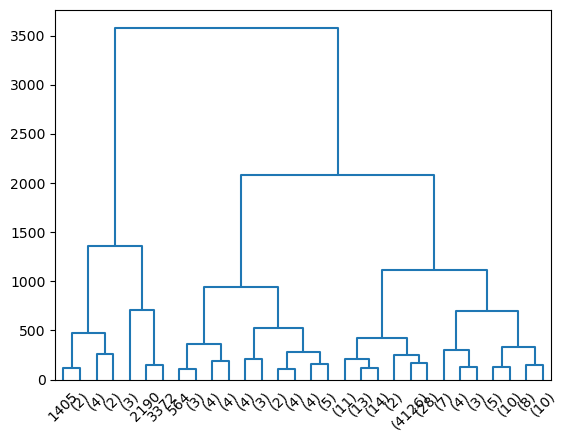

In [66]:
data_dist = pdist(X_scaled, metric='euclidean')
data_link = linkage(data_dist, method='complete', metric='euclidean')
res = dendrogram(data_link, color_threshold=1.0, truncate_mode='lastp')

#### Single link

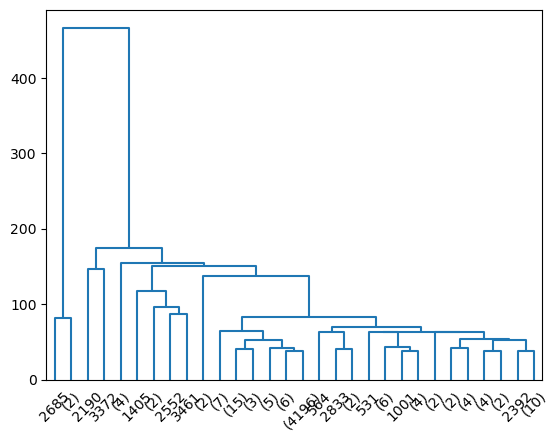

In [67]:
data_dist = pdist(X_scaled, metric='euclidean')
data_link = linkage(data_dist, method='single', metric='euclidean')
res = dendrogram(data_link, color_threshold=0.2, truncate_mode='lastp')

#### Average

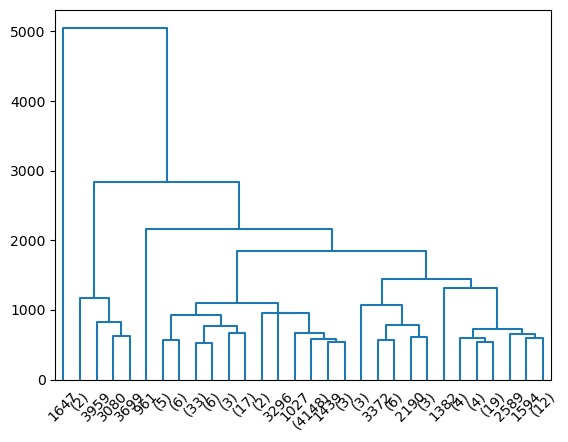

In [68]:
data_dist = pdist(X, metric='euclidean')
data_link = linkage(data_dist, method='average', metric='euclidean')
res = dendrogram(data_link, color_threshold=0.4, truncate_mode='lastp')

In [69]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

linkages = ['ward', 'complete', 'average']
K = range(2, 11)

results_hc = []
best_link = None
best_k = None
best_sil = -1
best_labels = None

for link in linkages:
    for k in K:
        if link == 'ward':
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage='ward'
            )
        else:
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=link,
                metric='euclidean'
            )

        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)

        results_hc.append((link, k, sil))
        print(f"linkage={link:8s}, k={k} -> silhouette={sil:.3f}")

        if sil > best_sil:
            best_sil = sil
            best_link = link
            best_k = k
            best_labels = labels

print("\nBest hierarchical configuration:")
print(f"linkage={best_link}, k={best_k}, silhouette={best_sil:.3f}")

patients['cluster_hier'] = best_labels


linkage=ward    , k=2 -> silhouette=0.973
linkage=ward    , k=3 -> silhouette=0.972
linkage=ward    , k=4 -> silhouette=0.965
linkage=ward    , k=5 -> silhouette=0.942
linkage=ward    , k=6 -> silhouette=0.943
linkage=ward    , k=7 -> silhouette=0.942
linkage=ward    , k=8 -> silhouette=0.942
linkage=ward    , k=9 -> silhouette=0.930
linkage=ward    , k=10 -> silhouette=0.930
linkage=complete, k=2 -> silhouette=0.973
linkage=complete, k=3 -> silhouette=0.972
linkage=complete, k=4 -> silhouette=0.972
linkage=complete, k=5 -> silhouette=0.963
linkage=complete, k=6 -> silhouette=0.962
linkage=complete, k=7 -> silhouette=0.962
linkage=complete, k=8 -> silhouette=0.956
linkage=complete, k=9 -> silhouette=0.956
linkage=complete, k=10 -> silhouette=0.956
linkage=average , k=2 -> silhouette=0.973
linkage=average , k=3 -> silhouette=0.972
linkage=average , k=4 -> silhouette=0.971
linkage=average , k=5 -> silhouette=0.965
linkage=average , k=6 -> silhouette=0.964
linkage=average , k=7 -> silhoue

In [70]:
hc = AgglomerativeClustering(
    n_clusters=best_k,
    linkage=best_link,
    metric='euclidean' if best_link != 'ward' else None
)
hc_labels = hc.fit_predict(X_scaled)

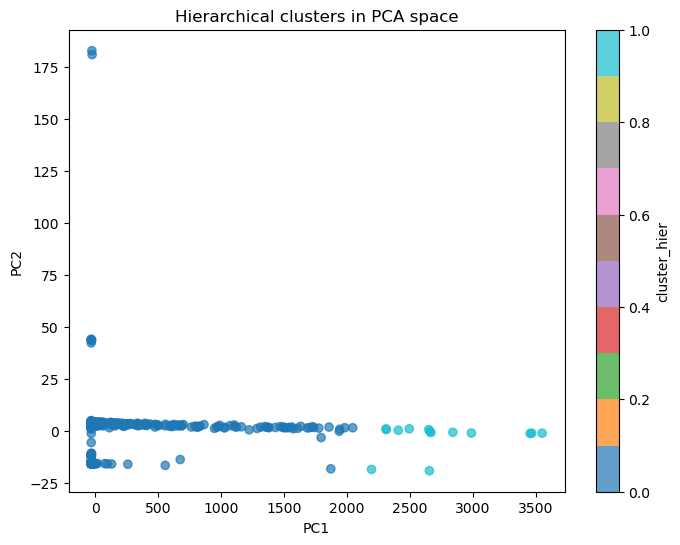

In [71]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hc_labels,        
    cmap='tab10',
    alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hierarchical clusters in PCA space')
plt.colorbar(scatter, label='cluster_hier')
plt.show()

## Final evaluation

To be done

## **Optional**: alternative clustering

We use `pyclustering` to explore other various type of clustering.  

In [72]:
!pip install pyclustering

### X-means

`X-means` can provide useful information. It extends KMeans and automatically chooses the number of clusters using BIC-like criteria (*Bayesian Information Criterion*).

In [73]:
from pyclustering.cluster.xmeans import xmeans, kmeans_plusplus_initializer
import numpy as np
import warnings
np.warnings = warnings

data = X_scaled.values

initial_centers = kmeans_plusplus_initializer(
    data,
    amount_centers=2      # starting k (e.g. 2)
).initialize()

xmeans_instance = xmeans(
    data=data,
    initial_centers=initial_centers,
    kmax=10               # maximum clusters to search
)

xmeans_instance.process()

clusters = xmeans_instance.get_clusters()       # list of lists of indices
centers  = xmeans_instance.get_centers()

print(f"Found {len(clusters)} clusters")


Found 10 clusters


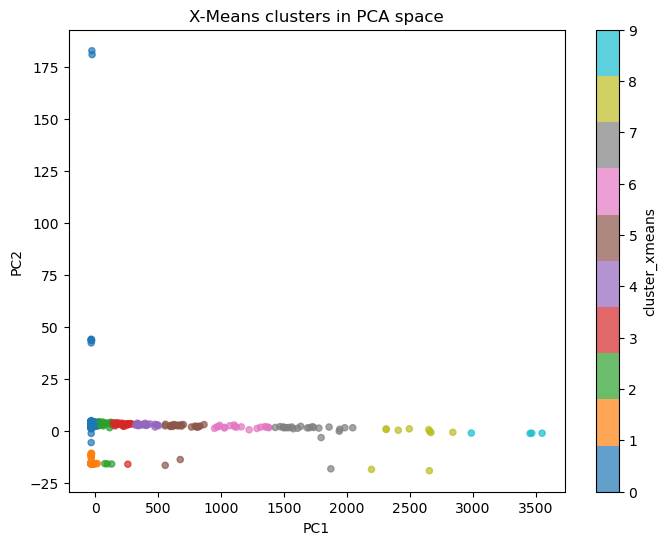

In [74]:
labels_xmeans = np.empty(data.shape[0], dtype=int)
for idx_cluster, indices in enumerate(clusters):
    labels_xmeans[indices] = idx_cluster

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=labels_xmeans, cmap='tab10', alpha=0.7, s=20)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('X-Means clusters in PCA space')
plt.colorbar(scatter, label='cluster_xmeans')
plt.show()

### CURE

### GMeans